# How and when to select subgoals?

In [2]:
PATH = '../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c/'

CKPT_NUM = 1000000

In [3]:
import json
import os

import numpy as np

from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset, CGCDataset
from utils.flax_utils import restore_agent

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [4]:
flags_path = os.path.join(PATH, 'flags.json')
with open(flags_path, 'r') as f:
    saved_flags = json.load(f)


In [5]:
agent_config = saved_flags['agent']
agent_config['subgoal_steps'] = 1000

In [6]:
dataset_class_name = agent_config.get('dataset_class', 'GCDataset')
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
    'CGCDataset': CGCDataset,
}[dataset_class_name]

dataset_path = os.path.join(PATH, 'data-100000.npz')
dataset_npz = np.load(dataset_path)
train_dataset = dataset_class(Dataset.create(**dict(dataset_npz)), config=agent_config)

seed = saved_flags.get('seed', 0)
example_batch = train_dataset.sample(1)

first_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
first_agent = restore_agent(first_agent, PATH, CKPT_NUM)

print(f'Restored first_agent from checkpoint {CKPT_NUM}')

Restored from ../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c//params_1000000.pkl
Restored first_agent from checkpoint 1000000


In [7]:
dqc_agent = first_agent

In [8]:
from tqdm import tqdm

all_cells = {}

for ob in tqdm(train_dataset.dataset['observations']):
    key = (np.floor(ob[0]), np.floor(ob[1]))
    if key in all_cells:
        all_cells[key] += 1
    else:
        all_cells[key] = 1

all_cell_points = np.asarray(list(all_cells.keys()))

  0%|          | 0/2000000 [00:00<?, ?it/s]

100%|██████████| 2000000/2000000 [00:10<00:00, 182461.27it/s]


## Flow set-up

In [9]:
saved_flags['env_name']

'humanoidmaze-large-navigate-singletask-task5-v0'

In [10]:
config = dict(
    env_name='humanoidmaze-large-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=100000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=1000,
    discount=0.995,
    flow_steps=10,
    backup_horizon=25,
    goal_conditioned=False,
)

config

{'env_name': 'humanoidmaze-large-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 100000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 1000,
 'discount': 0.995,
 'flow_steps': 10,
 'backup_horizon': 25,
 'goal_conditioned': False}

In [11]:
from wrappers.datafuncs_utils import make_env_and_datasets

env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = CGCDataset(base_train_dataset, config=config)

In [12]:
from utils.networks import ActorVectorField
from __future__ import annotations

from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from utils.datasets import GCDataset
from utils.flax_utils import TrainState, nonpytree_field
from utils.networks import ActorVectorField, MLP
from wrappers.datafuncs_utils import make_env_and_datasets


In [13]:
class GCFlowGoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def flow_loss(self, batch, grad_params=None, rng=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']] if self.config['goal_conditioned'] else None
        target_actions = batch[self.config['actions_key']]

        batch_size, action_dim = target_actions.shape
        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, action_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_actions
        vel = target_actions - x_0

        pred_vel = self.network(
            observations,
            goals=goals,
            actions=x_t,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_vel - vel))
        mae = jnp.mean(jnp.abs(pred_vel - vel))
        return loss, {
            'flow_loss': loss,
            'velocity_mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params, rng=rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals, rng):
        single_example = observations.ndim == 1
        if not self.config['goal_conditioned']:
            goals = None
        if single_example:
            observations = observations[None, ...]
            if goals is not None:
                goals = goals[None, ...]

        x = jax.random.normal(rng, (observations.shape[0], self.config['action_dim']))

        for i in range(self.config['flow_steps']):
            t = jnp.full((observations.shape[0], 1), i / self.config['flow_steps'])
            vels = self.network(observations, goals=goals, actions=x, times=t)
            x = x + vels / self.config['flow_steps']

        return x[0] if single_example else x

    @classmethod
    def create(cls, example_batch, config):
        config = dict(config)
        config.setdefault('goal_conditioned', True)
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = ActorVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        init_goals = example_batch[config['goal_key']] if config['goal_conditioned'] else None
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            goals=init_goals,
            actions=example_batch[config['actions_key']],
            times=example_batch[config['actions_key']][..., :1],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config['action_dim'] = action_dim
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))

In [14]:
example_batch = train_dataset.sample(1)
flow_agent = GCFlowGoalProposerAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, flow_agent.network.params)

flow_loss_history = []
velocity_mae_history = []

for step in range(1, config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    flow_agent, info = flow_agent.update(batch)

    flow_loss_history.append(float(info['flow_loss']))
    velocity_mae_history.append(float(info['velocity_mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} flow_loss={flow_loss_history[-1]:.6f} velocity_mae={velocity_mae_history[-1]:.6f}"
        )

step=00001 flow_loss=314.635254 velocity_mae=14.852587
step=00100 flow_loss=42.644333 velocity_mae=5.100490
step=00200 flow_loss=38.910423 velocity_mae=4.769796
step=00300 flow_loss=35.236210 velocity_mae=4.609067
step=00400 flow_loss=20.245367 velocity_mae=3.189251
step=00500 flow_loss=20.676445 velocity_mae=3.301721
step=00600 flow_loss=14.976452 velocity_mae=2.624607
step=00700 flow_loss=17.847164 velocity_mae=2.713592
step=00800 flow_loss=14.400656 velocity_mae=2.505826
step=00900 flow_loss=18.438726 velocity_mae=2.752554
step=01000 flow_loss=14.626576 velocity_mae=2.501133
step=01100 flow_loss=14.806490 velocity_mae=2.612603
step=01200 flow_loss=11.939379 velocity_mae=2.340622
step=01300 flow_loss=16.317364 velocity_mae=2.580918
step=01400 flow_loss=21.054193 velocity_mae=3.076378
step=01500 flow_loss=12.527082 velocity_mae=2.292822
step=01600 flow_loss=16.381992 velocity_mae=2.522160
step=01700 flow_loss=17.520807 velocity_mae=2.628854
step=01800 flow_loss=16.990746 velocity_mae=

100%|██████████| 200/200 [00:03<00:00, 52.30it/s]


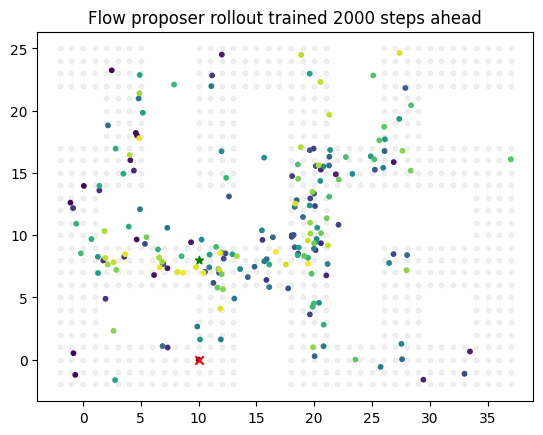

In [15]:
replay_buffer = []
# ob = np.asarray([20.0, 25.0])
# ob = np.asarray([0.0, 8.0])
# ob = np.asarray([5.0, 0.0])
# goal = np.asarray([20.0, 0.0])

# ob = np.asarray([15.0, 20.0])
ob = np.asarray([10.0, 0.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([10.0, 8.0])
rng = jax.random.PRNGKey(config['seed'])

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title(f'Flow proposer rollout trained {2000} steps ahead')
plt.show()

## Rolling out the raw DQC

100%|██████████| 2000/2000 [00:19<00:00, 104.46it/s]


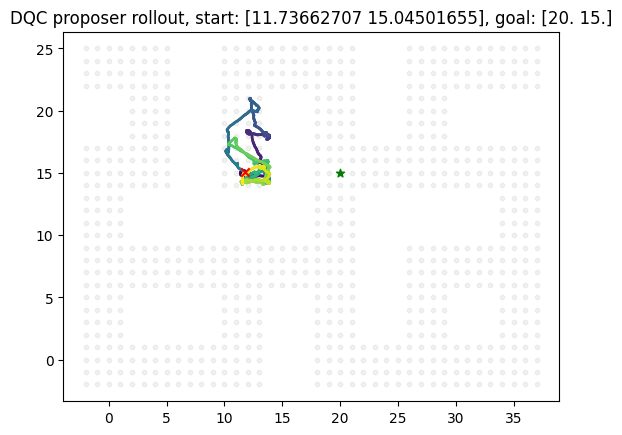

In [16]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
ob, _ = env.reset()
start = ob.copy()[:2]
# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([20.0, 15.0])

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

100%|██████████| 2000/2000 [00:11<00:00, 176.38it/s]


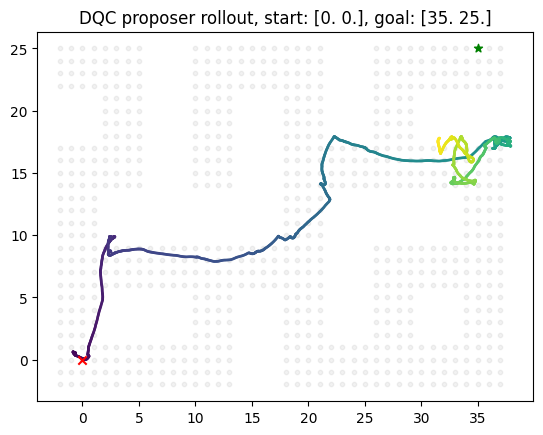

In [17]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
start = np.asarray([0.0, 0.0])

# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([35.0, 25.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

In [18]:
train_dataset.config['subgoal_steps']

1000

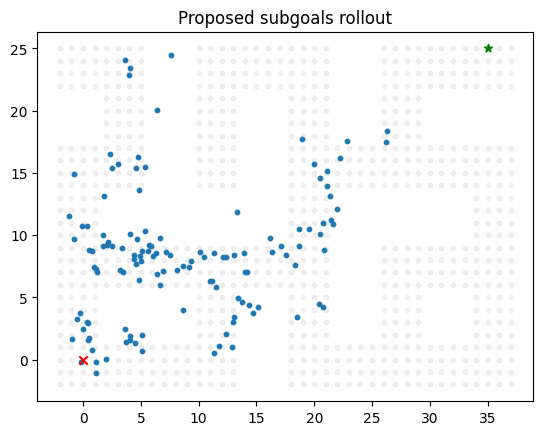

In [19]:
sample_rng, rng = jax.random.split(rng)
# subgoals = sample_n(start_ob, goal, 128, sample_rng)
# subgoals = flow_agent.sample_actions()
ob_xy = start[:2]
obs = np.repeat(ob_xy[None], 128, axis=0)
goals = np.repeat(goal[None], 128, axis=0)

sample_rng, rng = jax.random.split(rng)
subgoals = flow_agent.sample_actions(obs, goals, sample_rng)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Proposed subgoals rollout')
plt.show()

In [20]:
def sigmoid(x):
    x = np.asarray(x)
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x)),
    )

def value_xy(ob, subgoals, goal, agent=dqc_agent):
    assert subgoals.ndim > 1, 'did not provide multiple subgoals'
    subgoal_obs = np.repeat(ob[None], len(subgoals), axis=0)
    subgoal_obs[..., :2] = subgoals
    goals = np.repeat(goal[None], len(subgoals), axis=0)

    vs = agent.network.select('value')(subgoal_obs, goals)
    return vs

def dynamical_distance(ob, subgoals, goal, agent=dqc_agent):

    all_obs = np.repeat(ob[None], len(subgoals), axis=0)
    ob_to_subgoal_vs = agent.network.select('value')(all_obs, subgoals)
    subgoal_to_goal_vs = value_xy(ob, subgoals, goal)
    ob_to_goal_v = agent.network.select('value')(ob, goal)

    ob_to_subgoal_vs = sigmoid(ob_to_subgoal_vs)
    subgoal_to_goal_vs = sigmoid(subgoal_to_goal_vs)
    ob_to_goal_v = sigmoid(ob_to_goal_v)

    gamma_to_subgoal = np.log(np.clip(ob_to_subgoal_vs, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])
    gamma_to_goal = np.log(np.clip(subgoal_to_goal_vs, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])
    ob_to_goal = np.log(np.clip(ob_to_goal_v, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])

    return gamma_to_subgoal, gamma_to_goal, ob_to_goal

[0. 0.]
[-0.509788    0.97696575]
582.3720804171379


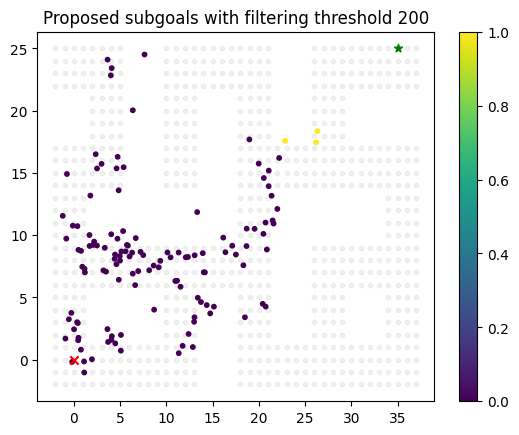

In [21]:
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)

print(start)
print(ob[:2])

thresh = 200
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10, c=(gamma_to_goal < ob_to_goal - thresh))

print(ob_to_goal)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'Proposed subgoals with filtering threshold {thresh}')
plt.colorbar(c)
plt.show()

582.3720804171379


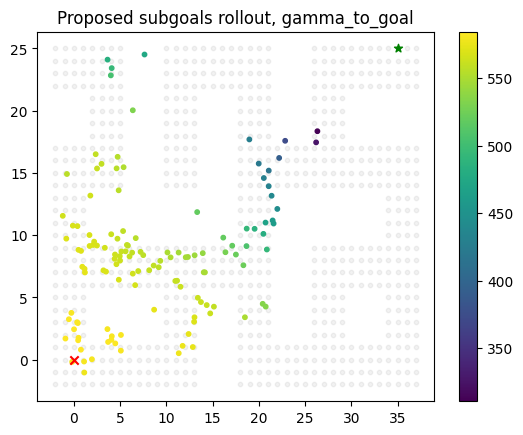

In [22]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
a = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10, c=gamma_to_goal)

print(ob_to_goal)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Proposed subgoals rollout, gamma_to_goal')
plt.colorbar(a)
plt.show()

582.3720804171379


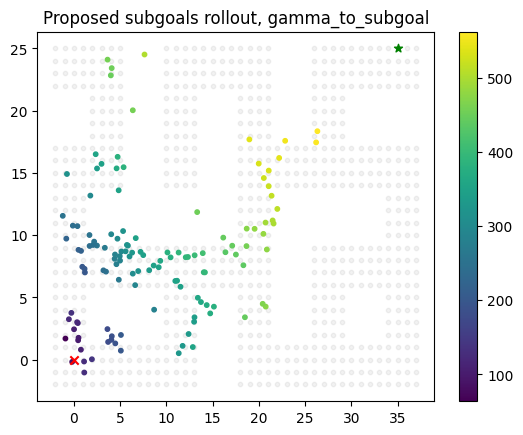

In [23]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
a = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10, c=gamma_to_subgoal)

print(ob_to_goal)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Proposed subgoals rollout, gamma_to_subgoal')
plt.colorbar(a)
plt.show()

582.3720804171379


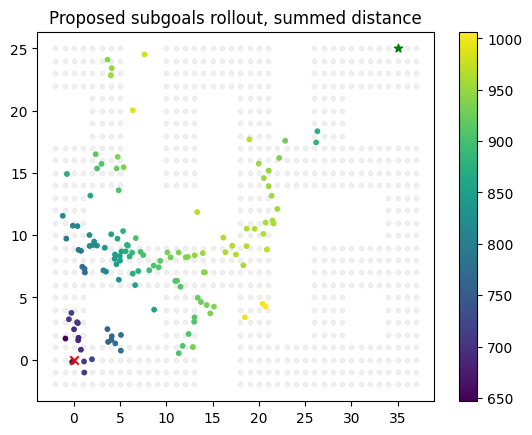

In [24]:
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
a = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10, c=gamma_to_subgoal + gamma_to_goal)

print(ob_to_goal)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Proposed subgoals rollout, summed distance')
plt.colorbar(a)
plt.show()

## Rollouts

In [25]:
def sample_n(ob, goal, n, sample_rng, agent=flow_agent):
    ob_xy = ob[:2]
    obs = np.repeat(ob_xy[None], n, axis=0)
    goals = np.repeat(goal[None], n, axis=0)

    return flow_agent.sample_actions(obs, goals, sample_rng)

In [26]:
replay_buffer = []
subgoals_buffer = []

start = np.asarray([0.0, 0.0])

# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([35.0, 25.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)
subgoal = None

to_subgoal = 0

for i in tqdm(range(2000)):
    replay_buffer.append(ob)

    if subgoal is None or to_subgoal == 1000:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        # rng, sample_rng = jax.random.split(rng)
        # second_subgoals = flow_agent.sample_actions(subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        # rng, sample_rng = jax.random.split(rng)
        # third_subgoals = flow_agent.sample_actions(second_subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal * 0.9
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (gamma_to_subgoal)[mask] # + gamma_to_goal
        subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

100%|██████████| 2000/2000 [00:11<00:00, 175.20it/s]


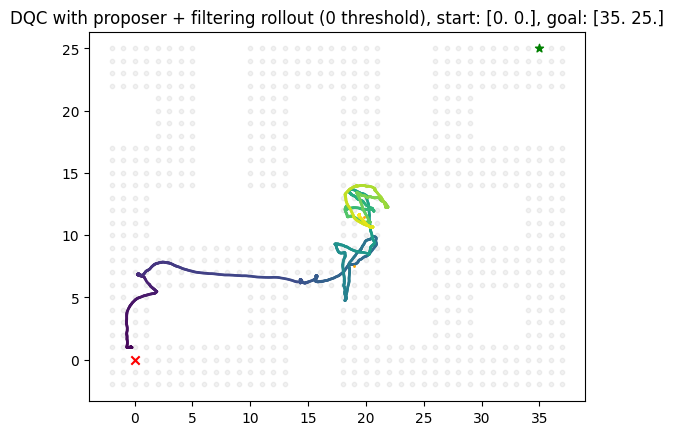

In [27]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout (0 threshold), start: {start}, goal: {goal}')
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:10<00:00, 183.68it/s]


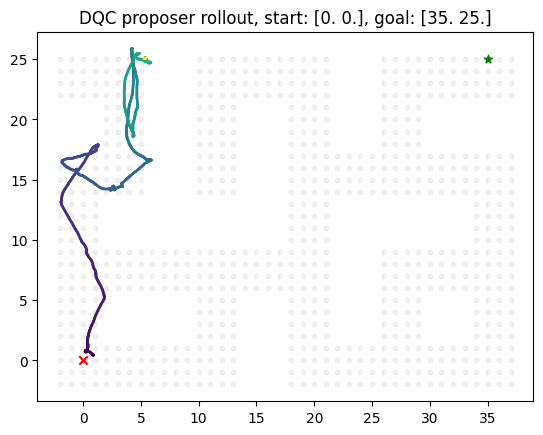

In [28]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
start = np.asarray([0.0, 0.0])

# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([35.0, 25.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

In [29]:
replay_buffer = []
subgoals_buffer = []

start = np.asarray([11.0, 15.0])

# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([35.0, 24.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)
subgoal = None

to_subgoal = 0

for i in tqdm(range(2000)):
    replay_buffer.append(ob)

    if subgoal is None or to_subgoal == 25:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        # rng, sample_rng = jax.random.split(rng)
        # second_subgoals = flow_agent.sample_actions(subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        # rng, sample_rng = jax.random.split(rng)
        # third_subgoals = flow_agent.sample_actions(second_subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal * 0.9
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]
        subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:30<00:00, 64.90it/s] 


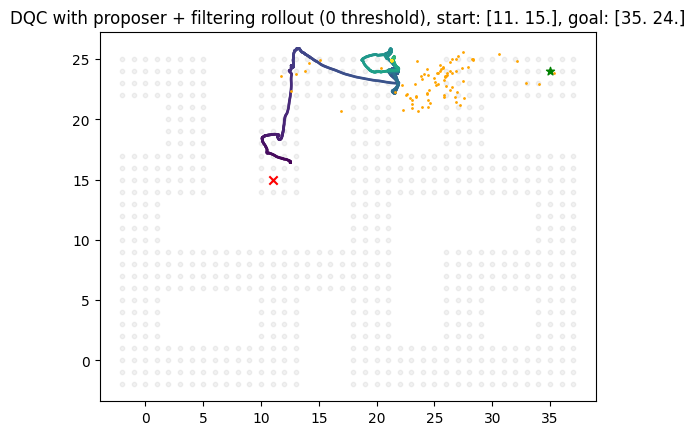

In [30]:
replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout (0 threshold), start: {start}, goal: {goal}')
plt.show()

100%|██████████| 2000/2000 [00:10<00:00, 199.34it/s]


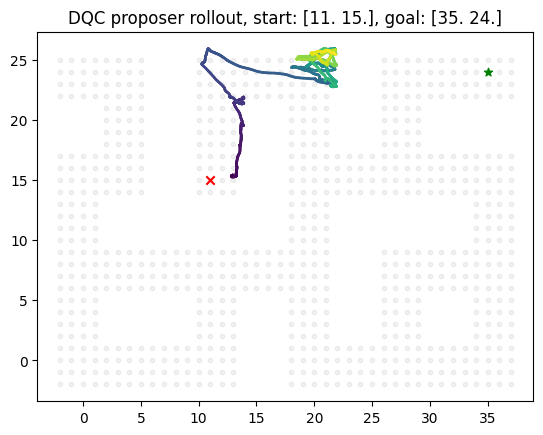

In [31]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
start = np.asarray([11.0, 15.0])

# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([35.0, 24.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:26<00:00, 75.85it/s] 


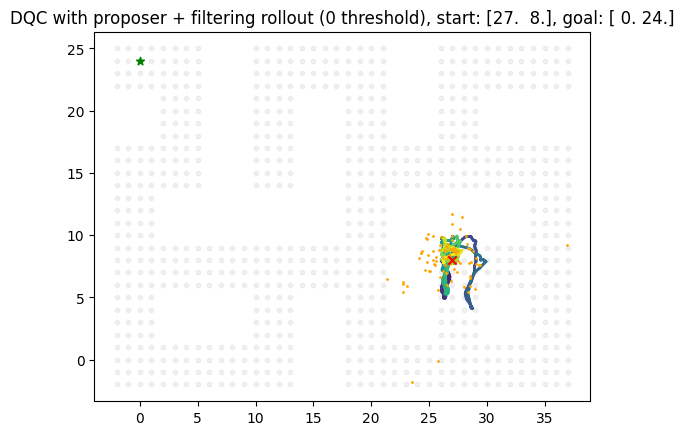

In [32]:
replay_buffer = []
subgoals_buffer = []

start = np.asarray([27.0, 8.0])

# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([0.0, 24.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)
subgoal = None

to_subgoal = 0

for i in tqdm(range(2000)):
    replay_buffer.append(ob)

    if subgoal is None or to_subgoal == 25:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        # rng, sample_rng = jax.random.split(rng)
        # second_subgoals = flow_agent.sample_actions(subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        # rng, sample_rng = jax.random.split(rng)
        # third_subgoals = flow_agent.sample_actions(second_subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        mask = gamma_to_goal < ob_to_goal * 1.0
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (gamma_to_subgoal)[mask] # + gamma_to_goal
        subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout (0 threshold), start: {start}, goal: {goal}')
plt.show()

In [33]:
tupled_all_cell_points = list(map(tuple, all_cell_points))
def in_maze(xy):
    # print(xy)
    return tuple(xy) in tupled_all_cell_points

100%|██████████| 2000/2000 [00:32<00:00, 60.76it/s]


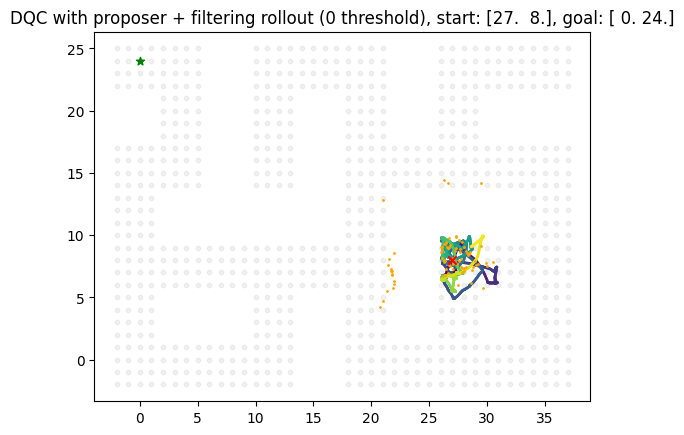

In [34]:
replay_buffer = []
subgoals_buffer = []

start = np.asarray([27.0, 8.0])

# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([0.0, 24.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)
subgoal = None

to_subgoal = 0

for i in tqdm(range(2000)):
    replay_buffer.append(ob)

    if subgoal is None or to_subgoal == 25:
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

        # rng, sample_rng = jax.random.split(rng)
        # second_subgoals = flow_agent.sample_actions(subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        # rng, sample_rng = jax.random.split(rng)
        # third_subgoals = flow_agent.sample_actions(second_subgoals, np.repeat(goal[None], 128, axis=0), sample_rng)

        gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
        gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
        gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
        ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

        subgoals_rounded = np.floor(subgoals)

        rounded_in = np.zeros_like(gamma_to_goal, dtype=bool)
        for i in range(len(subgoals_rounded)):
            rounded_in[i] = float(in_maze(subgoals_rounded[i, :2]))

        mask = (gamma_to_goal < ob_to_goal * 1.0) * rounded_in

        
        if not np.any(mask):
            print(f'no improving subgoal found at step {s}')
            break

        filtered_subgoals = subgoals[mask]
        filtered_scores = (gamma_to_subgoal)[mask] # + gamma_to_goal
        subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]
        subgoals_buffer.append(subgoal)
        to_subgoal = 0

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=subgoal, seed=action_rng)
    to_subgoal += 1
    ob, reward, terminated, truncated, _ = env.step(action)

    if np.linalg.norm(ob[:2] - subgoal) < 0.1:
        subgoal = None
    
    if np.linalg.norm(ob[:2] - goal) < 0.05:
        print('finished')
        break

replay_buffer = np.asarray(replay_buffer)
subgoals_buffer = np.asarray(subgoals_buffer)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=subgoals_buffer[..., 0], y=subgoals_buffer[..., 1], c='orange', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC with proposer + filtering rollout (0 threshold), start: {start}, goal: {goal}')
plt.show()

In [35]:
print(list(map(tuple, subgoals)))

[(2.5246978, -0.6809293), (19.726328, 7.134292), (19.21938, 2.4552646), (26.077131, 0.8204102), (28.59674, 6.8277254), (22.720156, -1.2845664), (27.092602, 22.14865), (24.88776, 15.795391), (19.456654, 17.239685), (14.078941, 15.54155), (26.01681, -0.27952236), (25.893452, -0.88721067), (18.959408, 9.168471), (28.441055, 8.459064), (21.33058, 6.3328686), (27.331491, 15.25412), (23.08972, 5.9090166), (36.172195, 14.363466), (20.755442, 8.667311), (20.677025, 6.418005), (29.380518, -0.42674267), (19.63878, 12.208044), (29.19319, 5.7913203), (0.95976603, 11.150406), (29.249233, 13.952852), (20.55991, -0.20168144), (16.07625, 25.154785), (20.014559, 2.7662458), (15.071862, 1.7681859), (11.172689, 6.9786224), (24.00077, 15.275243), (7.963866, 9.398495), (15.04132, 7.48865), (26.728956, 15.054652), (26.916056, 0.4746442), (20.713505, 6.633993), (18.683842, 1.814447), (35.345776, 7.3276978), (27.917788, 8.237853), (32.710297, 15.994067), (28.342213, 12.137887), (11.830463, 9.034307), (20.6123

100%|██████████| 2000/2000 [00:10<00:00, 184.50it/s]


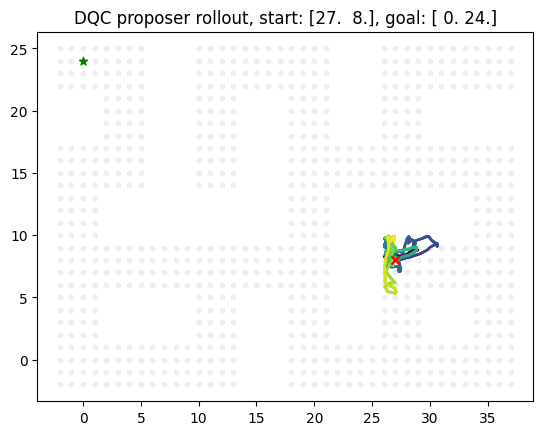

In [36]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
start = np.asarray([27.0, 8.0])

# start = np.asarray([28.0, 8.0])
# ob[:2] = start.copy()
goal = np.asarray([0.0, 24.0])
ob, _ = env.reset(
    options=dict(
        task_info=dict(
            init_ij=env.unwrapped.xy_to_ij(start),
            goal_ij=env.unwrapped.xy_to_ij(goal)
        )
    )
)

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=1)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title(f'DQC proposer rollout, start: {start}, goal: {goal}')
plt.show()